<span style="color: green; font-weight: bold;">
Supervised Machine Learning Algorithms (Linear Regression, Logistic Regression, SVM, Random Forest)
</span>

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as snsa
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [3]:
data = pd.read_csv('AI_JobMarketTrends_2026.csv')
data

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
0,1,AI Engineer,Startup,Retail,Canada,Remote,Senior,2,Master,0,0,0,1,0,158322,6,2024,Low,4
1,2,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,1,1,0,1,163666,11,2026,High,9
2,3,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14,Master,1,0,1,0,1,158556,3,2026,High,9
3,4,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,9,Master,0,1,0,1,1,95775,3,2025,High,7
4,5,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5,Master,1,1,1,0,0,111873,12,2021,Low,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10340,10341,Data Engineer,Startup,Technology,USA,Onsite,Entry,2,PhD,1,0,1,0,1,76426,4,2023,Low,4
10341,10342,Data Analyst,Medium,Healthcare,Australia,Hybrid,Entry,10,Master,1,1,0,0,1,61233,9,2024,Medium,6
10342,10343,Machine Learning Engineer,Startup,Education,Germany,Hybrid,Entry,4,PhD,0,0,0,1,0,103681,3,2026,Low,4
10343,10344,Data Engineer,MNC,E-commerce,Canada,Hybrid,Mid,5,PhD,1,1,1,0,0,112895,12,2024,High,9


In [4]:
data_copy = data
data_copy

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
0,1,AI Engineer,Startup,Retail,Canada,Remote,Senior,2,Master,0,0,0,1,0,158322,6,2024,Low,4
1,2,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,1,1,0,1,163666,11,2026,High,9
2,3,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14,Master,1,0,1,0,1,158556,3,2026,High,9
3,4,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,9,Master,0,1,0,1,1,95775,3,2025,High,7
4,5,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5,Master,1,1,1,0,0,111873,12,2021,Low,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10340,10341,Data Engineer,Startup,Technology,USA,Onsite,Entry,2,PhD,1,0,1,0,1,76426,4,2023,Low,4
10341,10342,Data Analyst,Medium,Healthcare,Australia,Hybrid,Entry,10,Master,1,1,0,0,1,61233,9,2024,Medium,6
10342,10343,Machine Learning Engineer,Startup,Education,Germany,Hybrid,Entry,4,PhD,0,0,0,1,0,103681,3,2026,Low,4
10343,10344,Data Engineer,MNC,E-commerce,Canada,Hybrid,Mid,5,PhD,1,1,1,0,0,112895,12,2024,High,9


In [5]:
data_copy.dtypes

job_id                   int64
job_title               object
company_size            object
company_industry        object
country                 object
remote_type             object
experience_level        object
years_experience         int64
education_level         object
skills_python            int64
skills_sql               int64
skills_ml                int64
skills_deep_learning     int64
skills_cloud             int64
salary                   int64
job_posting_month        int64
job_posting_year         int64
hiring_urgency          object
job_openings             int64
dtype: object

In [6]:
data_copy.describe()

,job_id,years_experience,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,job_openings
count,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.00000,10345.000000,10345.000000,10345.00000
mean,5173.000000,6.950507,0.493088,0.503045,0.507878,0.498018,0.511455,113438.22726,6.502465,2023.000387,5.00406
std,2986.488601,4.320054,0.499976,0.500015,0.499962,0.500020,0.499893,31389.20106,3.473441,1.996856,2.58382
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45083.00000,1.000000,2020.000000,1.00000
25%,2587.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,89715.00000,4.000000,2021.000000,3.00000
50%,5173.000000,7.000000,0.000000,1.000000,1.000000,0.000000,1.000000,113082.00000,6.000000,2023.000000,5.00000
75%,7759.000000,11.000000,1.000000,1.000000,1.000000,1.000000,1.000000,134894.00000,10.000000,2025.000000,7.00000
max,10345.000000,14.000000,1.000000,1.000000,1.000000,1.000000,1.000000,204143.00000,12.000000,2026.000000,9.00000


In [7]:
data_copy.shape

(10345, 19)

In [8]:
 data.isnull().sum()

job_id                  0
job_title               0
company_size            0
company_industry        0
country                 0
remote_type             0
experience_level        0
years_experience        0
education_level         0
skills_python           0
skills_sql              0
skills_ml               0
skills_deep_learning    0
skills_cloud            0
salary                  0
job_posting_month       0
job_posting_year        0
hiring_urgency          0
job_openings            0
dtype: int64

In [9]:
data_copy.duplicated().sum()

np.int64(0)

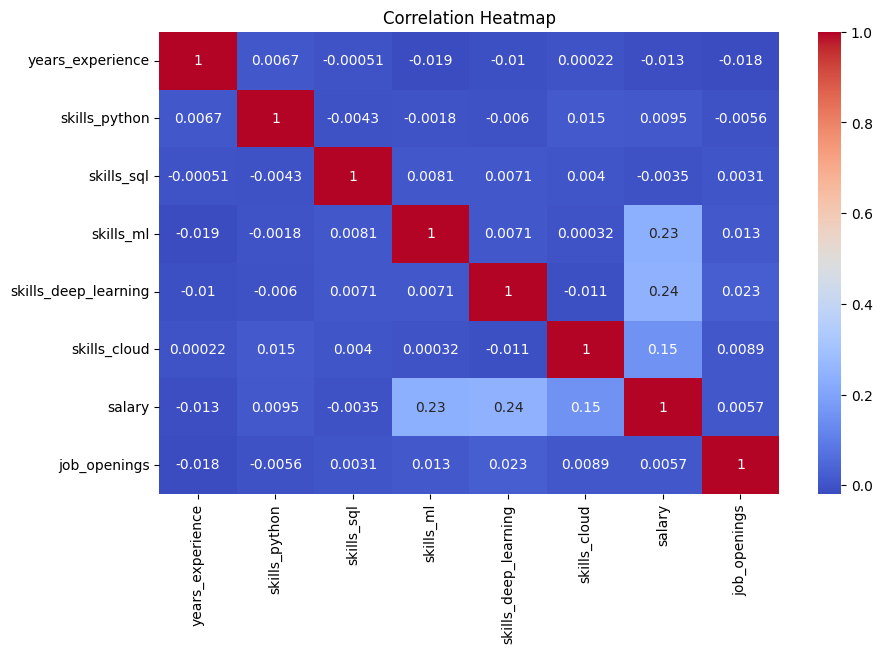

In [10]:
numeric_cols = [
    'years_experience', 'skills_python', 'skills_sql', 
    'skills_ml', 'skills_deep_learning', 'skills_cloud', 
    'salary', 'job_openings'
]

plt.figure(figsize=(10,6))
sns.heatmap(data[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

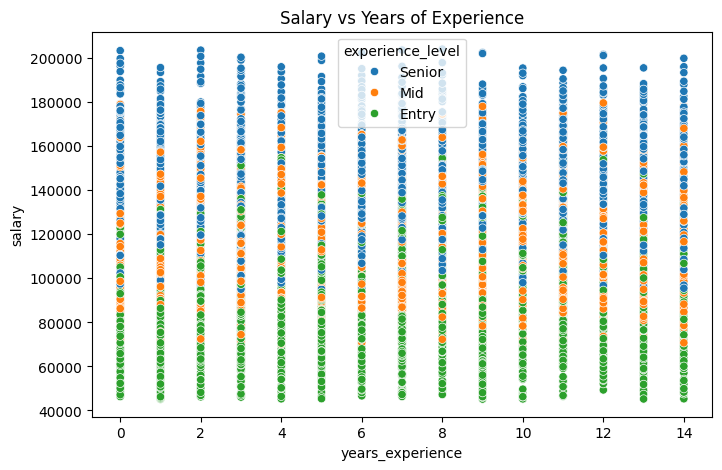

In [11]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='years_experience', y='salary', data=data, hue='experience_level')
plt.title("Salary vs Years of Experience")
plt.show()

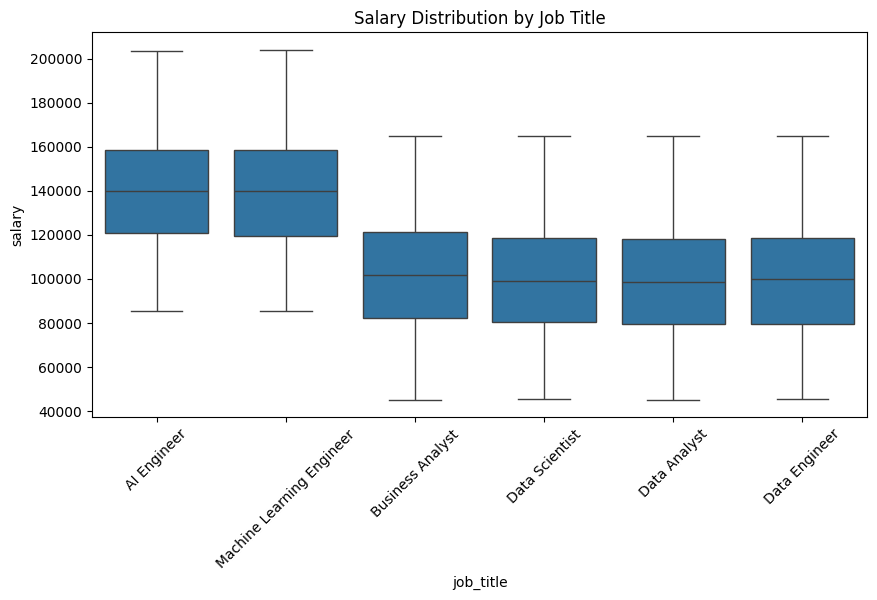

In [12]:
plt.figure(figsize=(10,5))
sns.boxplot(x='job_title', y='salary', data=data)
plt.xticks(rotation=45)
plt.title("Salary Distribution by Job Title")
plt.show()

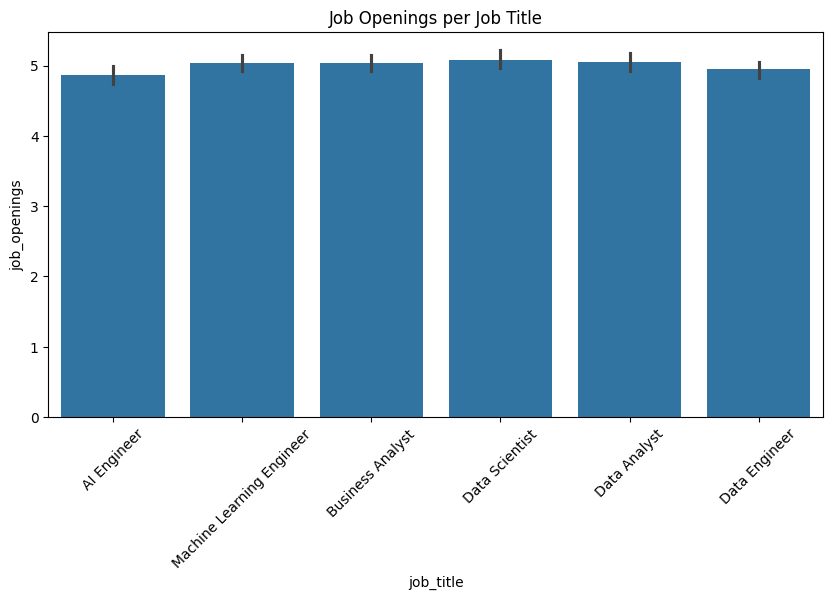

In [13]:
plt.figure(figsize=(10,5))
sns.barplot(x='job_title', y='job_openings', data=data_copy)
plt.xticks(rotation=45)
plt.title("Job Openings per Job Title")
plt.show()

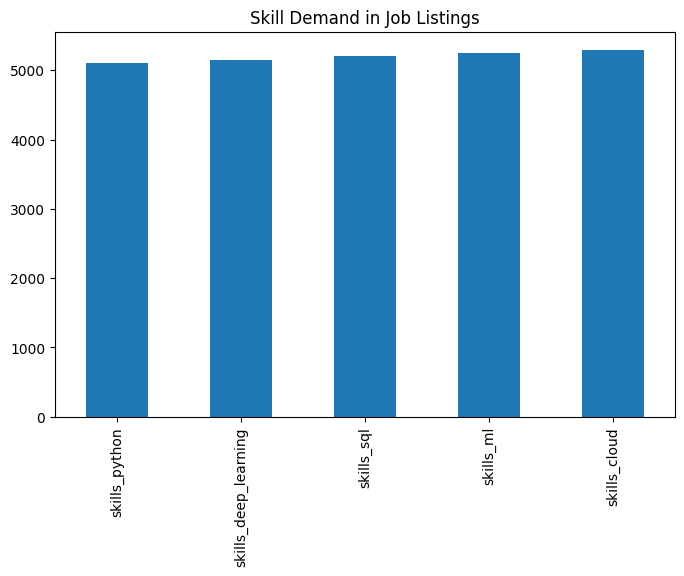

In [14]:
skill_cols = ['skills_python','skills_sql','skills_ml','skills_deep_learning','skills_cloud']

skill_sum = data_copy[skill_cols].sum().sort_values()

plt.figure(figsize=(8,5))
skill_sum.plot(kind='bar')
plt.title("Skill Demand in Job Listings")
plt.show()

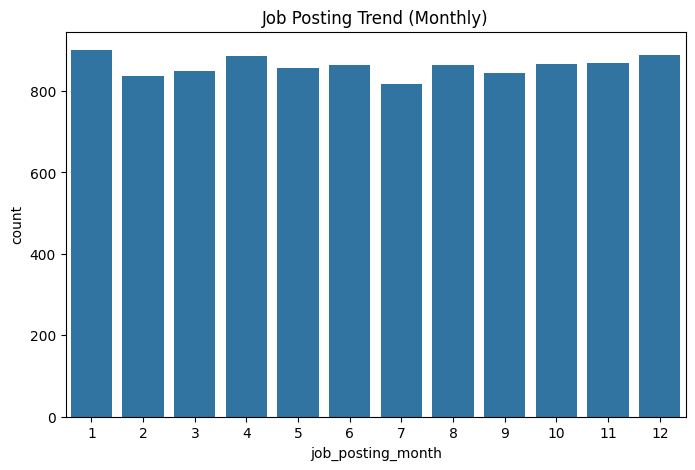

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(x='job_posting_month', data=data_copy)
plt.title("Job Posting Trend (Monthly)")
plt.show()

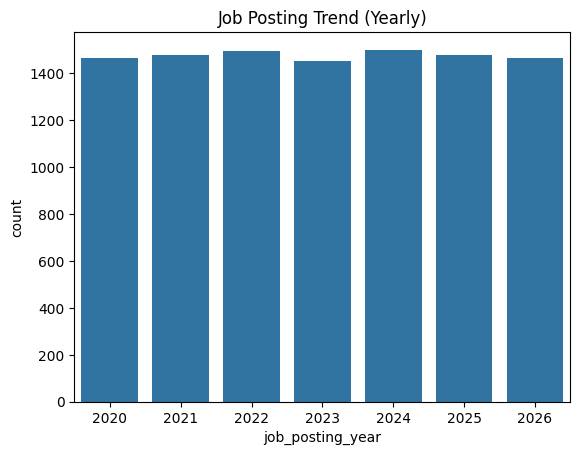

In [16]:
sns.countplot(x='job_posting_year', data=data_copy)
plt.title("Job Posting Trend (Yearly)")
plt.show()

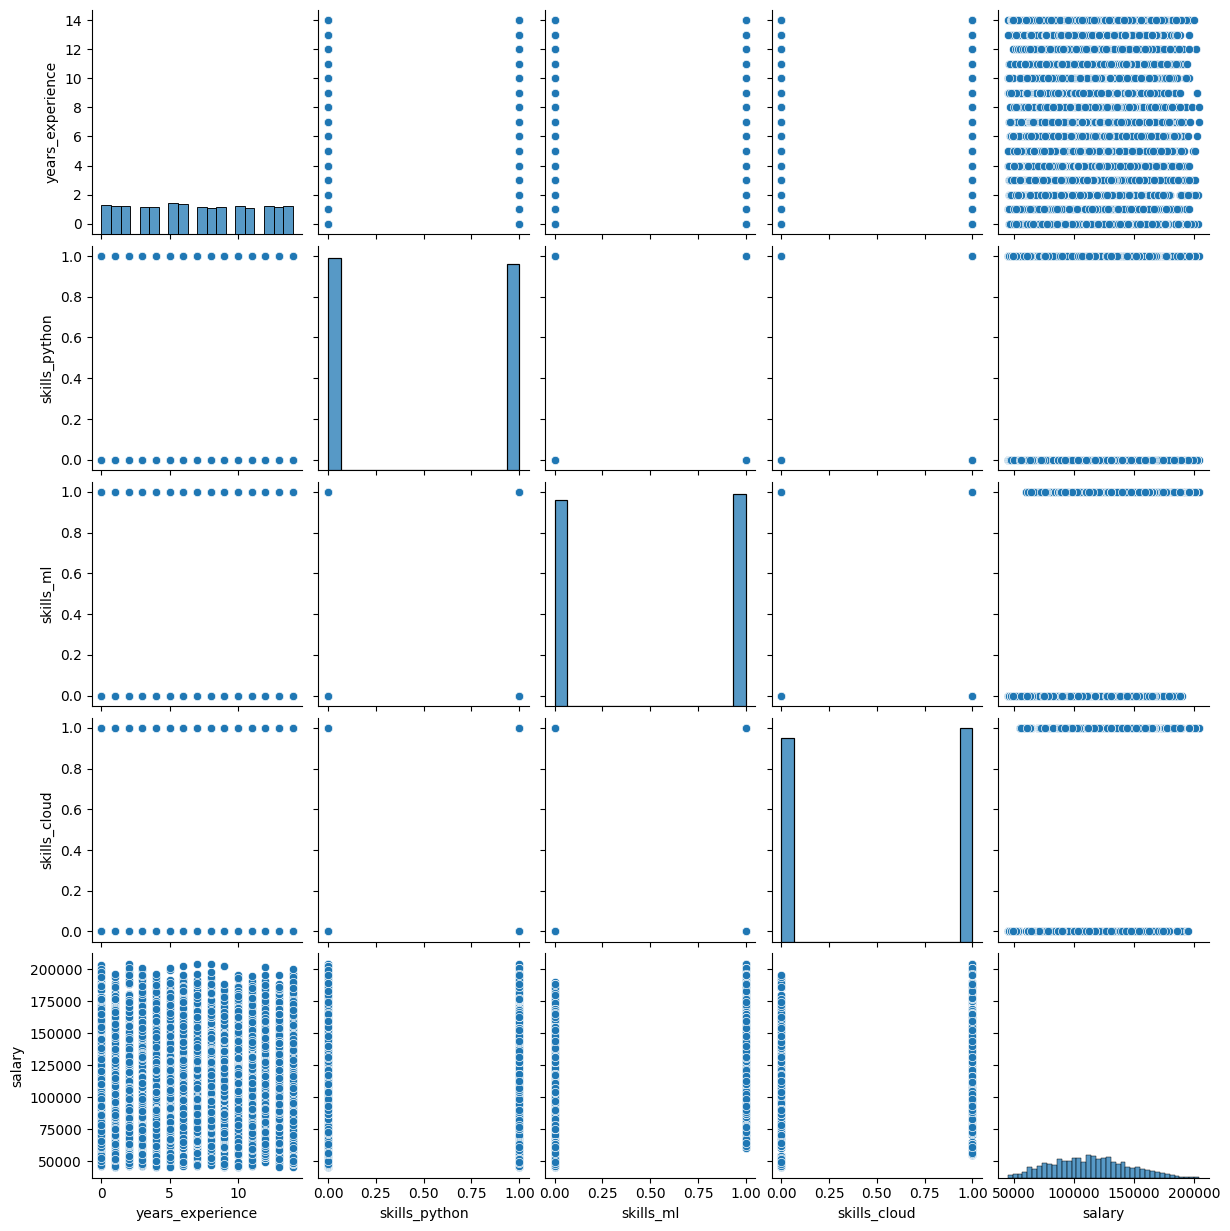

In [17]:
sns.pairplot(data_copy[['years_experience','skills_python','skills_ml','skills_cloud','salary']])
plt.show()

In [18]:
data_copy.columns

Index(['job_id', 'job_title', 'company_size', 'company_industry', 'country',
       'remote_type', 'experience_level', 'years_experience',
       'education_level', 'skills_python', 'skills_sql', 'skills_ml',
       'skills_deep_learning', 'skills_cloud', 'salary', 'job_posting_month',
       'job_posting_year', 'hiring_urgency', 'job_openings'],
      dtype='object')

In [19]:
data_copy['job_title'].unique()

array(['AI Engineer', 'Machine Learning Engineer', 'Business Analyst',
       'Data Scientist', 'Data Analyst', 'Data Engineer'], dtype=object)

In [20]:
data_copy['company_size'].unique()

array(['Startup', 'MNC', 'Medium', 'Enterprise'], dtype=object)

In [21]:
data_copy['company_industry'].unique()

array(['Retail', 'Technology', 'Healthcare', 'Finance', 'Education',
       'E-commerce'], dtype=object)

In [22]:
data_copy['country'].nunique()

7

In [23]:
data_copy['remote_type'].unique()

array(['Remote', 'Hybrid', 'Onsite'], dtype=object)

In [24]:
data_copy['experience_level'].unique()

array(['Senior', 'Mid', 'Entry'], dtype=object)

In [25]:
data_copy['years_experience'].unique()

array([ 2,  0, 14,  9,  5,  6,  4, 10, 13,  3, 12, 11,  8,  1,  7])

In [26]:
data_copy['education_level'].unique()

array(['Master', 'Bachelor', 'PhD'], dtype=object)

In [27]:
data_copy['job_openings'].unique()

array([4, 9, 7, 2, 8, 3, 5, 6, 1])

In [28]:
data_copy['hiring_urgency'].unique()

array(['Low', 'High', 'Medium'], dtype=object)

In [29]:
data_copy['job_title'] = (
    data_copy['job_title']
    .replace({
        'AI Engineer': 0,
        'Machine Learning Engineer': 1,
        'Business Analyst': 2,
        'Data Scientist': 3,
        'Data Analyst': 4,
        'Data Engineer': 5
    })
    .infer_objects(copy=False)
    .astype(int)
)

C:\Users\logi\AppData\Local\Temp\ipykernel_3236\3172993482.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({


In [30]:
data_copy

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
0,1,0,Startup,Retail,Canada,Remote,Senior,2,Master,0,0,0,1,0,158322,6,2024,Low,4
1,2,1,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,1,1,0,1,163666,11,2026,High,9
2,3,1,MNC,Technology,Germany,Onsite,Mid,14,Master,1,0,1,0,1,158556,3,2026,High,9
3,4,2,Startup,Healthcare,Germany,Remote,Mid,9,Master,0,1,0,1,1,95775,3,2025,High,7
4,5,3,MNC,Healthcare,Germany,Hybrid,Mid,5,Master,1,1,1,0,0,111873,12,2021,Low,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10340,10341,5,Startup,Technology,USA,Onsite,Entry,2,PhD,1,0,1,0,1,76426,4,2023,Low,4
10341,10342,4,Medium,Healthcare,Australia,Hybrid,Entry,10,Master,1,1,0,0,1,61233,9,2024,Medium,6
10342,10343,1,Startup,Education,Germany,Hybrid,Entry,4,PhD,0,0,0,1,0,103681,3,2026,Low,4
10343,10344,5,MNC,E-commerce,Canada,Hybrid,Mid,5,PhD,1,1,1,0,0,112895,12,2024,High,9


In [31]:
data_copy['company_size'] = data_copy['company_size'].replace({
    'Startup': 0,
    'MNC': 1,
    'Medium': 2,
    'Enterprise': 3,
    
}) .infer_objects(copy=False).astype(int)

C:\Users\logi\AppData\Local\Temp\ipykernel_3236\349207617.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_copy['company_size'] = data_copy['company_size'].replace({


In [32]:
data_copy['experience_level'] = (
    data_copy['experience_level']
    .replace({
        'Senior': 0,
        'Mid': 1,
        'Entry': 2
    })
    .infer_objects(copy=False)
    .astype(int)
)

C:\Users\logi\AppData\Local\Temp\ipykernel_3236\1967821808.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({


In [33]:
data_copy['education_level'] = (
    data_copy['education_level']
    .replace({
        'Master': 0,
        'Bachelor': 1,
        'PhD': 2
    })
    .infer_objects(copy=False)
    .astype(int)
)

C:\Users\logi\AppData\Local\Temp\ipykernel_3236\1659935659.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({


In [34]:
data_copy['education_level'].unique()

array([0, 1, 2])

In [35]:
data_copy

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
0,1,0,0,Retail,Canada,Remote,0,2,0,0,0,0,1,0,158322,6,2024,Low,4
1,2,1,1,Technology,Australia,Hybrid,1,0,1,1,1,1,0,1,163666,11,2026,High,9
2,3,1,1,Technology,Germany,Onsite,1,14,0,1,0,1,0,1,158556,3,2026,High,9
3,4,2,0,Healthcare,Germany,Remote,1,9,0,0,1,0,1,1,95775,3,2025,High,7
4,5,3,1,Healthcare,Germany,Hybrid,1,5,0,1,1,1,0,0,111873,12,2021,Low,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10340,10341,5,0,Technology,USA,Onsite,2,2,2,1,0,1,0,1,76426,4,2023,Low,4
10341,10342,4,2,Healthcare,Australia,Hybrid,2,10,0,1,1,0,0,1,61233,9,2024,Medium,6
10342,10343,1,0,Education,Germany,Hybrid,2,4,2,0,0,0,1,0,103681,3,2026,Low,4
10343,10344,5,1,E-commerce,Canada,Hybrid,1,5,2,1,1,1,0,0,112895,12,2024,High,9


In [36]:
data_copy.describe()

,job_id,job_title,company_size,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,job_openings
count,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.00000,10345.000000,10345.000000,10345.00000
mean,5173.000000,2.476462,1.482165,1.008990,6.950507,0.989947,0.493088,0.503045,0.507878,0.498018,0.511455,113438.22726,6.502465,2023.000387,5.00406
std,2986.488601,1.702738,1.120666,0.818635,4.320054,0.819861,0.499976,0.500015,0.499962,0.500020,0.499893,31389.20106,3.473441,1.996856,2.58382
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45083.00000,1.000000,2020.000000,1.00000
25%,2587.000000,1.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,89715.00000,4.000000,2021.000000,3.00000
50%,5173.000000,2.000000,1.000000,1.000000,7.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,113082.00000,6.000000,2023.000000,5.00000
75%,7759.000000,4.000000,2.000000,2.000000,11.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,134894.00000,10.000000,2025.000000,7.00000
max,10345.000000,5.000000,3.000000,2.000000,14.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,204143.00000,12.000000,2026.000000,9.00000


In [37]:
data_copy.isna().sum()

job_id                  0
job_title               0
company_size            0
company_industry        0
country                 0
remote_type             0
experience_level        0
years_experience        0
education_level         0
skills_python           0
skills_sql              0
skills_ml               0
skills_deep_learning    0
skills_cloud            0
salary                  0
job_posting_month       0
job_posting_year        0
hiring_urgency          0
job_openings            0
dtype: int64

In [38]:
data_copy.describe().columns

Index(['job_id', 'job_title', 'company_size', 'experience_level',
       'years_experience', 'education_level', 'skills_python', 'skills_sql',
       'skills_ml', 'skills_deep_learning', 'skills_cloud', 'salary',
       'job_posting_month', 'job_posting_year', 'job_openings'],
      dtype='object')

<span style="color: red; font-weight: bold;">LINEAR REGRESSION (salary)</span>

In [39]:
feature_cols = [
    'job_title', 'company_size', 'experience_level',
       'years_experience', 'education_level', 'skills_python', 'skills_sql',
       'skills_ml', 'skills_deep_learning', 'skills_cloud',
       'job_posting_month', 'job_posting_year', 'job_openings'
]

X = data_copy[feature_cols]
y = data_copy['salary']

In [40]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)

In [41]:
scaler = StandardScaler()
X_trains = scaler.fit_transform(X_train)
X_tests = scaler.transform(X_test)

In [42]:
model = LinearRegression()
model.fit(X_trains, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [43]:
y_pred = model.predict(X_tests)

In [44]:
print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.8065183499395752
MSE: 192648811.74556717


In [45]:
from sklearn.pipeline import Pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


In [46]:
new_data = {
    'job_title': 3,
    'company_size': 2,
    'experience_level': 1,
    'years_experience': 4,
    'education_level': 2,
    'skills_python': 1,
    'skills_sql': 1,
    'skills_ml': 1,
    'skills_deep_learning': 0,
    'skills_cloud': 1,
    'job_posting_month': 5,
    'job_posting_year': 2024,
    'job_openings': 3
}

In [47]:
new_df = pd.DataFrame([new_data], columns=feature_cols)

In [48]:
predicted_salary = pipeline.predict(new_df)[0]
print("Predicted Salary:", predicted_salary)

Predicted Salary: 112688.83003668653


<span style="color: red; font-weight: bold;">Logistic REGRESSION (Hiring Urgency)</span>

In [49]:
data_copy['hiring_urgency'] = data_copy['hiring_urgency'].replace({
    'Low': 0,
    'Medium': 0,
    'High': 2
}).astype(int)

C:\Users\logi\AppData\Local\Temp\ipykernel_3236\3810086881.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_copy['hiring_urgency'] = data_copy['hiring_urgency'].replace({


In [50]:
feature_cols = [
    'job_title', 'company_size', 'experience_level',
    'years_experience', 'education_level', 'skills_python', 'skills_sql',
    'skills_ml', 'skills_deep_learning', 'skills_cloud',
    'job_posting_month', 'job_posting_year', 'job_openings'
]

X = data_copy[feature_cols]
y = data_copy['hiring_urgency']

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [52]:
from sklearn.linear_model import LogisticRegression

logit_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression())
])

In [53]:
model = LogisticRegression()
model.fit(X_trains, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [54]:
logit_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('logit', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

In [55]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = logit_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8443692605123247

Confusion Matrix:
 [[863 179]
 [143 884]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.83      0.84      1042
           2       0.83      0.86      0.85      1027

    accuracy                           0.84      2069
   macro avg       0.84      0.84      0.84      2069
weighted avg       0.84      0.84      0.84      2069



In [56]:
new_data = {
    'job_title': 3,
    'company_size': 2,
    'experience_level': 1,
    'years_experience': 4,
    'education_level': 2,
    'skills_python': 1,
    'skills_sql': 1,
    'skills_ml': 1,
    'skills_deep_learning': 0,
    'skills_cloud': 1,
    'job_posting_month': 5,
    'job_posting_year': 2024,
    'job_openings': 3
}

new_df = pd.DataFrame([new_data], columns=feature_cols)

prediction = logit_model.predict(new_df)[0]
probability = logit_model.predict_proba(new_df)[0][1]

print("Predicted (1=Urgent, 0=Not urgent):", prediction)
print("Urgency Probability:", probability)

Predicted (1=Urgent, 0=Not urgent): 0
Urgency Probability: 0.104287423843774


<span style="color: red; font-weight: bold;">Random Forest</span>

In [57]:
feature_cols = [
    'job_title', 'company_size', 'experience_level',
    'years_experience', 'education_level', 'skills_python', 'skills_sql',
    'skills_ml', 'skills_deep_learning', 'skills_cloud',
    'job_posting_month', 'job_posting_year', 'job_openings'
]

X = data_copy[feature_cols]
y = data_copy['hiring_urgency']

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [59]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [60]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
 [[1042    0]
 [   0 1027]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1042
           2       1.00      1.00      1.00      1027

    accuracy                           1.00      2069
   macro avg       1.00      1.00      1.00      2069
weighted avg       1.00      1.00      1.00      2069



<span style="color: red; font-weight: bold;">Support Vector Machine</span>

In [61]:
feature_cols = [
    'job_title', 'company_size', 'experience_level',
    'years_experience', 'education_level', 'skills_python', 'skills_sql',
    'skills_ml', 'skills_deep_learning', 'skills_cloud',
    'job_posting_month', 'job_posting_year', 'job_openings'
]

X = data_copy[feature_cols]
y = data_copy['hiring_urgency']

In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [70]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [72]:
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [73]:
y_pred = svm_model.predict(X_test_scaled)

In [74]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8458192363460609
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1042
           2       0.84      0.85      0.85      1027

    accuracy                           0.85      2069
   macro avg       0.85      0.85      0.85      2069
weighted avg       0.85      0.85      0.85      2069



In [75]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[879 163]
 [156 871]]


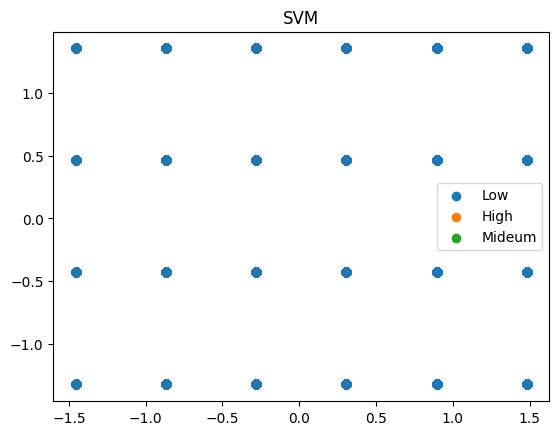

In [78]:
X_vis = X.iloc[:, :2].values   
y_vis = y.values
Scaler2 = StandardScaler()
X_vis_Scaled = Scaler2.fit_transform(X_vis)
SVM_vis =SVC(kernel='linear')
SVM_vis.fit(X_vis_Scaled,y_vis)
plt.scatter(X_vis_Scaled[y_vis ==0][:,0],X_vis_Scaled[y_vis==0][0:,1],label='Low')
plt.scatter(X_vis_Scaled[y_vis ==1][:,0],X_vis_Scaled[y_vis==1][0:,1],label='High')
plt.scatter(X_vis_Scaled[y_vis ==1][:,0],X_vis_Scaled[y_vis==1][0:,1],label='Mideum')

plt.legend()
plt.title("SVM")
plt.show()

In [79]:
# Select best features for SVM
svm_features = [
    'years_experience',
    'skills_python',
    'skills_sql',
    'skills_ml',
    'skills_deep_learning',
    'skills_cloud',
    'job_openings',
    'job_posting_month',
    'job_posting_year'
]

# X = input features
X = data_copy[svm_features]

# y = target variable
y = data_copy['hiring_urgency']

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [81]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [82]:
svm_model = SVC(kernel='linear')  # linear kernel for multiclass
svm_model.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [84]:
y_pred_svm = svm_model.predict(X_test_scaled)


In [85]:
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_svm))

SVM Accuracy: 0.8482358627356211

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.86      0.85      1030
           2       0.86      0.83      0.85      1039

    accuracy                           0.85      2069
   macro avg       0.85      0.85      0.85      2069
weighted avg       0.85      0.85      0.85      2069


Confusion Matrix:

[[890 140]
 [174 865]]


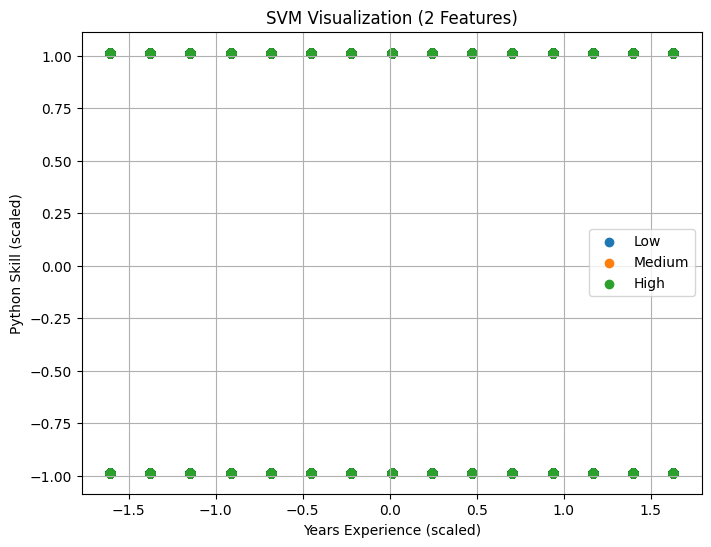

In [86]:
plt.figure(figsize=(8, 6))

plt.scatter(X_vis_scaled[y_vis == 0][:, 0], X_vis_scaled[y_vis == 0][:, 1], label="Low")
plt.scatter(X_vis_scaled[y_vis == 1][:, 0], X_vis_scaled[y_vis == 1][:, 1], label="Medium")
plt.scatter(X_vis_scaled[y_vis == 2][:, 0], X_vis_scaled[y_vis == 2][:, 1], label="High")

plt.xlabel("Years Experience (scaled)")
plt.ylabel("Python Skill (scaled)")
plt.title("SVM Visualization (2 Features)")
plt.legend()
plt.grid(True)
plt.show()

<span style="color: green; font-weight: bold;">
Unsupervised Machine Learning Algorithms (K-Means Clusters)
</span>

In [89]:
from sklearn.cluster import KMeans

In [91]:
data_copy.describe().columns

Index(['job_id', 'job_title', 'company_size', 'experience_level',
       'years_experience', 'education_level', 'skills_python', 'skills_sql',
       'skills_ml', 'skills_deep_learning', 'skills_cloud', 'salary',
       'job_posting_month', 'job_posting_year', 'hiring_urgency',
       'job_openings'],
      dtype='object')

In [92]:
X = data_copy[['job_title', 'company_size', 'experience_level',
       'years_experience', 'education_level', 'skills_python', 'skills_sql',
       'skills_ml', 'skills_deep_learning', 'skills_cloud', 'salary',
       'job_posting_month', 'job_posting_year', 'hiring_urgency',
       'job_openings']]
X

,job_title,company_size,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
0,0,0,0,2,0,0,0,0,1,0,158322,6,2024,0,4
1,1,1,1,0,1,1,1,1,0,1,163666,11,2026,2,9
2,1,1,1,14,0,1,0,1,0,1,158556,3,2026,2,9
3,2,0,1,9,0,0,1,0,1,1,95775,3,2025,2,7
4,3,1,1,5,0,1,1,1,0,0,111873,12,2021,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10340,5,0,2,2,2,1,0,1,0,1,76426,4,2023,0,4
10341,4,2,2,10,0,1,1,0,0,1,61233,9,2024,0,6
10342,1,0,2,4,2,0,0,0,1,0,103681,3,2026,0,4
10343,5,1,1,5,2,1,1,1,0,0,112895,12,2024,2,9


In [93]:
kmeans = KMeans(n_clusters=3, random_state=42)
data_copy['cluster'] = kmeans.fit_predict(X)

In [94]:
labels = kmeans.labels_

In [95]:
data_copy["cluster"] = labels
print(data_copy)

       job_id  job_title  company_size company_industry    country  \
0           1          0             0           Retail     Canada   
1           2          1             1       Technology  Australia   
2           3          1             1       Technology    Germany   
3           4          2             0       Healthcare    Germany   
4           5          3             1       Healthcare    Germany   
...       ...        ...           ...              ...        ...   
10340   10341          5             0       Technology        USA   
10341   10342          4             2       Healthcare  Australia   
10342   10343          1             0        Education    Germany   
10343   10344          5             1       E-commerce     Canada   
10344   10345          0             0        Education  Australia   

      remote_type  experience_level  years_experience  education_level  \
0          Remote                 0                 2                0   
1          

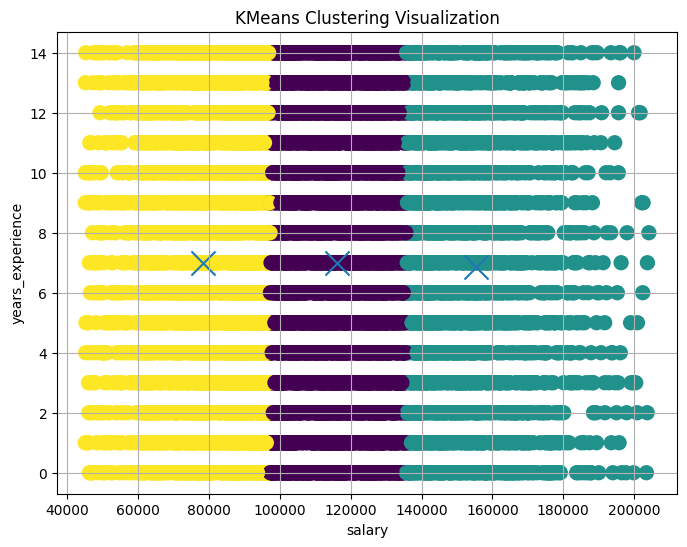

In [99]:
import matplotlib.pyplot as plt


x_col = 'salary'               
y_col = 'years_experience'     

plt.figure(figsize=(8,6))


plt.scatter(
    data_copy[x_col],
    data_copy[y_col],
    c=data_copy['cluster'],
    s=100
)


feature_names = X.columns.tolist()


i_x = feature_names.index(x_col)
i_y = feature_names.index(y_col)


centers = kmeans.cluster_centers_

plt.scatter(
    centers[:, i_x],
    centers[:, i_y],
    marker='x',
    s=300
)


plt.xlabel(x_col)
plt.ylabel(y_col)
plt.title('KMeans Clustering Visualization')
plt.grid(True)
plt.show()